Note: you may need to restart the kernel to use updated packages.

[INFO] Python libraries imported successfully.

[ERROR] Tesseract configuration failed!
Did you complete Step 1 and install the Tesseract software on Windows?
Error details: tesseract is not installed or it's not in your PATH. See README file for more information.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip


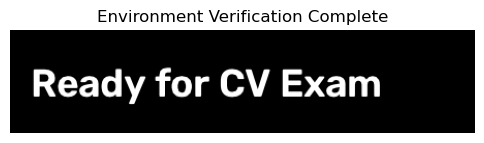

In [5]:
# Step 1: Install Tesseract for Windows

# Download the official Windows installer from the UB Mannheim repository: Tesseract at UB Mannheim.

# Download the 64-bit installer (e.g., tesseract-ocr-w64-setup-5.3.3.20231005.exe).

# Run the installer. Leave all settings as default. It will install to C:\Program Files\Tesseract-OCR.

# =====================================================================
# 1. INSTALL PYTHON LIBRARIES
# =====================================================================
# The % ensures it installs to the active Jupyter kernel
%pip install opencv-python numpy matplotlib pandas scikit-image pytesseract -q

import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 2. POINT PYTHON TO YOUR WINDOWS TESSERACT INSTALLATION
# If you installed Tesseract somewhere else, update this path!
# =====================================================================
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

print("\n[INFO] Python libraries imported successfully.")

# =====================================================================
# 3. ENVIRONMENT VALIDATION TEST
# =====================================================================
test_img = np.zeros((100, 450, 3), dtype=np.uint8)
cv2.putText(test_img, 'Ready for CV Exam', (20, 65), 
            cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 255), 2)

gray_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)
try:
    extracted = pytesseract.image_to_string(gray_img)
    print(f"[INFO] Tesseract OCR Extraction: '{extracted.strip()}'")
    print("[INFO] OCR is configured correctly.")
except Exception as e:
    print(f"\n[ERROR] Tesseract configuration failed!")
    print("Did you complete Step 1 and install the Tesseract software on Windows?")
    print(f"Error details: {e}")

# Display using Matplotlib
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Environment Verification Complete")
plt.axis('off')
plt.show()

In [ ]:
# =========================================================================================
# COMPUTER VISION EXAM - MASTER UTILITY SCRIPT
# This block contains modular functions to solve Exam Q1 (Segmentation/Features), 
# Exam Q2 (Video OCR), and Photometric Transformations.
# =========================================================================================

import cv2                  # Core computer vision library (reads in BGR format)
import numpy as np          # Matrix operations (images are just NumPy arrays)
import pytesseract          # Google's Optical Character Recognition (OCR) engine
from skimage.feature import hog  # Traditional feature extraction
import matplotlib.pyplot as plt  # Visualization library (expects RGB format)

# -----------------------------------------------------------------------------------------
# [CRITICAL FOR WINDOWS OFFLINE] TESSERACT PATH CONFIGURATION
# Pytesseract is just a wrapper. You MUST point it to the actual software installed on Windows.
# -----------------------------------------------------------------------------------------
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


# =========================================================================================
# 1. DYNAMIC DATA (VIDEO) PROCESSING & OCR
# [USE CASE]: Exam Q2 - Extracting credentials (username/password) from a hacked video.
# [CONCEPT]: A video is just a rapid sequence of image matrices (frames). We use a while 
#            loop to extract each frame, preprocess it, and run OCR to read the text.
# =========================================================================================
def extract_credentials_from_video(video_path, output_txt_file):
    # Initialize the video object
    cap = cv2.VideoCapture(video_path)
    extracted_data = set() # Set prevents writing the same password multiple times
    
    with open(output_txt_file, "w") as f:
        while cap.isOpened():
            ret, frame = cap.read() # ret is a boolean (True if frame grabbed successfully)
            if not ret:
                break # Video has ended
            
            # --- HOW TO MODIFY (ROI Cropping) ---
            # Running OCR on a 1080p frame is slow. If the login box is only in the middle, 
            # slice the NumPy array to only look at that specific Region of Interest (ROI).
            # Example: frame = frame[200:600, 400:800] # [y_start:y_end, x_start:x_end]
            
            # --- PREPROCESSING FOR OCR ---
            # OCR engines hate color and shadows. We convert to grayscale, then use a binary 
            # threshold to force the text to be pure black/white against the background.
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            
            # HOW TO MODIFY: The '150' is the threshold limit. If the video background is dark, 
            # lower this number (e.g., 100). If it's too bright, raise it (e.g., 200).
            _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
            
            # Execute OCR on the cleaned up frame
            text = pytesseract.image_to_string(thresh).strip()
            
            # --- HOW TO MODIFY (Keyword Search) ---
            # If the exam asks to find a "license plate", change the keywords below.
            if text and ("username" in text.lower() or "password" in text.lower()):
                if text not in extracted_data:
                    extracted_data.add(text)
                    f.write(text + "\n")
                    print(f"[SUCCESS] Found and saved: {text}")

    cap.release()
    print("Video processing complete.")


# =========================================================================================
# 2. COLOR-BASED SEGMENTATION (HSV MASKS)
# [USE CASE]: Exam Q1 - Isolating the 'Sea', 'Forest', or 'Road' from the drone image.
# [CONCEPT]: We NEVER segment color in RGB. RGB mixes color with lighting/shadows. 
#            HSV separates Hue (the actual color) from Saturation and Value (brightness).
# =========================================================================================
def segment_by_color(image_path, lower_hsv, upper_hsv):
    img = cv2.imread(image_path)
    
    # Convert BGR to HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # cv2.inRange creates a binary mask. Every pixel that falls between lower_hsv 
    # and upper_hsv becomes 255 (White). Everything else becomes 0 (Black).
    mask = cv2.inRange(hsv_img, np.array(lower_hsv), np.array(upper_hsv))
    
    # Bitwise AND acts like a stencil. It pastes the original colors ONLY where the mask is white.
    segmented_result = cv2.bitwise_and(img, img, mask=mask)
    
    # --- HOW TO MODIFY (HSV CHEAT SHEET FOR EXAM Q1) ---
    # In OpenCV, Hue is 0-179 (not 360). Saturation is 0-255. Value is 0-255.
    # To isolate FOREST (Green): lower_hsv=[35, 50, 50], upper_hsv=[85, 255, 255]
    # To isolate SEA (Blue):     lower_hsv=[90, 50, 50], upper_hsv=[130, 255, 255]
    # To isolate ROAD (Gray):    lower_hsv=[0, 0, 50],   upper_hsv=[180, 50, 200] (Low saturation)
    
    return mask, segmented_result


# =========================================================================================
# 3. K-MEANS CLUSTERING SEGMENTATION
# [USE CASE]: Exam Q1 - Segmenting an image automatically when you don't know the exact HSV bounds.
# [CONCEPT]: K-Means mathematically groups pixels into 'K' clusters based entirely on 
#            color/intensity similarity. It ignores the spatial location of the pixels.
# =========================================================================================
def segment_kmeans(image_path, K=3):
    img = cv2.imread(image_path)
    
    # K-Means requires a 2D array of pixels (Total Pixels, Channels). We reshape the 3D image.
    pixel_values = np.float32(img.reshape((-1, 3)))
    
    # --- STOPPING CRITERIA ---
    # Tell the algorithm to stop calculating when it hits 100 iterations (MAX_ITER) 
    # OR when the cluster centers move by less than 0.2 (EPS/Epsilon).
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    
    # Run K-Means. 'labels' tells us which cluster (0, 1, 2) each pixel belongs to. 
    # 'centers' are the dominant BGR colors of those clusters.
    _, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Reconstruct the image by coloring every pixel with its assigned cluster's center color
    centers = np.uint8(centers)
    segmented_img = centers[labels.flatten()].reshape(img.shape)
    
    # HOW TO MODIFY: Change 'K' when calling the function based on the exam prompt. 
    # E.g., For "Sea, Person, Road", K=3 or K=4 might work best.
    return segmented_img


# =========================================================================================
# 4. HOG FEATURE EXTRACTION (Histogram of Oriented Gradients)
# [USE CASE]: Exam Q1 - Detecting the 'Person' (Pedestrian) on the road.
# [CONCEPT]: Color segmentation fails on humans (we wear different colored clothes). HOG 
#            ignores color entirely and looks at edge gradients (shapes/silhouettes).
# =========================================================================================
def extract_hog_features(image_path):
    # HOG operates on shapes and intensity, so we load in Grayscale immediately.
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # --- HOW TO MODIFY (Resizing) ---
    # HOG is computationally heavy. Standard pedestrian detection uses 64x128 or 128x256 ratios.
    # If the drone image is massive, HOG will crash or take 5 minutes. Resize it!
    img = cv2.resize(img, (128, 256)) 
    
    # pixels_per_cell: Divides the image into 8x8 grids.
    # orientations: Calculates the edge angles into 9 "bins" (0 to 180 degrees).
    features, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=True)
    
    # 'features' is the raw mathematical 1D array.
    # 'hog_image' is the visual representation of the gradients (edges) you can plot.
    return features, hog_image


# =========================================================================================
# 5. PHOTOMETRIC TRANSFORMATIONS (MISSING LAB 02)
# [USE CASE]: Medical imaging (X-Rays/Ultrasound) or murky drone footage.
# [CONCEPT]: Geometric transformations move pixels. Photometric mathematically alters color/light.
# =========================================================================================
def apply_gamma_correction(img, gamma=1.0):
    # Gamma applies a power-law curve: s = c * r^gamma
    # We use a Lookup Table (LUT) to pre-calculate all 256 possible pixel values. 
    # Applying an LUT is 100x faster than doing math on every single pixel in Python loops.
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    
    # --- HOW TO MODIFY ---
    # gamma < 1.0: Expands dark regions, reveals soft tissue in X-Rays.
    # gamma > 1.0: Darkens the image, reducing harsh contrast.
    return cv2.LUT(img, table)

def apply_log_transform(img):
    # Formula: s = c * log(1 + r)
    # Automatically expands the dark background regions to reveal faint outer edges.
    c = 255 / np.log(1 + np.max(img))
    log_image = c * (np.log(img + 1))
    log_image = np.array(log_image, dtype=np.uint8)
    return log_image


# =========================================================================================
# 6. SAFE VISUALIZATION HELPER
# [USE CASE]: Use this to plot your Before/After results for the exam answers.
# [CONCEPT]: OpenCV defaults to BGR format. Matplotlib explicitly expects RGB. 
#            If you don't convert, the Red and Blue channels swap, making images look alien.
# =========================================================================================
def show_comparison(img1, img2, title1="Original", title2="Processed"):
    plt.figure(figsize=(10, 5))
    
    # Plot Image 1
    plt.subplot(1, 2, 1)
    # Check if the image is color (3 channels) or grayscale (2 channels)
    if len(img1.shape) == 3: 
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # Fix the BGR bug
    plt.imshow(img1, cmap='gray' if len(img1.shape) == 2 else None)
    plt.title(title1)
    plt.axis('off')
    
    # Plot Image 2
    plt.subplot(1, 2, 2)
    if len(img2.shape) == 3: 
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    plt.imshow(img2, cmap='gray' if len(img2.shape) == 2 else None)
    plt.title(title2)
    plt.axis('off')
    
    plt.show()